In [20]:
%matplotlib inline

import tqdm
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import torch_geometric as pyg
import matplotlib.pyplot as plt
import torch.nn.functional as F
import community as community_louvain

from tqdm import tqdm
from sklearn.manifold import TSNE
from torch_sparse import SparseTensor
from torch_geometric.utils import to_networkx
from torch.utils.data import DataLoader, SubsetRandomSampler

from common.utils import Utils

In [21]:
N_SAMPLES = 50_000

DEFAULT_VAL_FIG_SIZE = (25, 20)
DEFAULT_VAL_TITLE_SIZE = 15
DEFAULT_VAL_LABEL_SIZE = 12

In [22]:
dataset = pyg.datasets.Reddit2(
    root="./data"
    , transform=pyg.transforms.Compose(
        [
            pyg.transforms.NormalizeFeatures()
            , pyg.transforms.ToSparseTensor()
        ]
    )
)

In [23]:
print(f'Number of graphs: {len(dataset)}')
print('-' * 100)
print(f'Number of nodes: {dataset[0].num_nodes:,}')
print(f'Number of node features: {dataset.num_node_features:,}')
print(f'X tensor shape: {dataset.x.shape}')
print(f'Average node degree: {dataset[0].num_edges / dataset[0].num_nodes:.2f}')
print('-' * 100)
print(f'Number of edges: {dataset[0].num_edges:,}')
print(f'Number of edge features: {dataset.num_edge_features:,}')
print(f'Edge Index tensor shape: {dataset.edge_index.shape}')
print('-' * 100)
print(f'Number of classes: {dataset.num_classes:,}')
print(f'Y tensor shape: {dataset.y.shape}')
print('-' * 100)
print(f'Has isolated nodes: {dataset[0].has_isolated_nodes()}')
print(f'Has self-loops: {dataset[0].has_self_loops()}')
print(f'Is undirected: {dataset[0].is_undirected()}')
print('-' * 100)
print(f'Number of training nodes: {dataset.train_mask.sum():,}')
print(f'Training nodes rate: {int(dataset.train_mask.sum()) / dataset[0].num_nodes:.2f}')
print('-' * 100)
print(f'Number of validation nodes: {dataset.val_mask.sum():,}')
print(f'Validation nodes rate: {int(dataset.val_mask.sum()) / dataset[0].num_nodes:.2f}')
print('-' * 100)
print(f'Number of test nodes: {dataset.test_mask.sum():,}')
print(f'Test nodes rate: {int(dataset.test_mask.sum()) / dataset[0].num_nodes:.2f}')

Number of graphs: 1
----------------------------------------------------------------------------------------------------
Number of nodes: 232,965
Number of node features: 602
X tensor shape: torch.Size([232965, 602])
Average node degree: 99.65
----------------------------------------------------------------------------------------------------
Number of edges: 23,213,838
Number of edge features: 0
Edge Index tensor shape: torch.Size([2, 23213838])
----------------------------------------------------------------------------------------------------
Number of classes: 41
Y tensor shape: torch.Size([232965])
----------------------------------------------------------------------------------------------------
Has isolated nodes: True
Has self-loops: False
Is undirected: True
----------------------------------------------------------------------------------------------------
Number of training nodes: 153,932
Training nodes rate: 0.66
------------------------------------------------------------

In [24]:
df_X = pd.DataFrame(data=dataset[0].x.numpy())
df_Y = pd.DataFrame(data=dataset[0].y.numpy(), columns=["community"])

In [25]:
print("Dataframe X shape:", df_X.shape)
print("Dataframe X head:")
print(df_X.head())

Dataframe X shape: (232965, 602)
Dataframe X head:
        0         1         2         3         4         5         6     
0  0.072471  0.881639  0.000078  0.000081  0.000075  0.000077  0.000077  \
1  0.031391  0.007558  0.001749  0.001550  0.001693  0.001632  0.001513   
2  0.036715  0.019144  0.001701  0.001592  0.001661  0.001701  0.001640   
3  0.031362  0.007552  0.001754  0.001643  0.001721  0.001589  0.001589   
4  0.009580  0.309404  0.001145  0.001239  0.001316  0.001116  0.001132   

        7         8         9    ...       592       593       594       595   
0  0.000089  0.000069  0.000081  ...  0.000076  0.000076  0.000077  0.000070  \
1  0.001571  0.001517  0.001691  ...  0.001570  0.001614  0.001626  0.001481   
2  0.001574  0.001604  0.001476  ...  0.001520  0.001619  0.001538  0.001378   
3  0.001697  0.001679  0.001634  ...  0.001610  0.001542  0.001609  0.001484   
4  0.001231  0.001030  0.001206  ...  0.001117  0.001121  0.001134  0.001066   

        596      

In [26]:
print("Dataframe Y shape:", df_Y.shape)
print("Dataframe Y head:")
print(df_Y.head())

Dataframe Y shape: (232965, 1)
Dataframe Y head:
   community
0         30
1         17
2         18
3         23
4         22


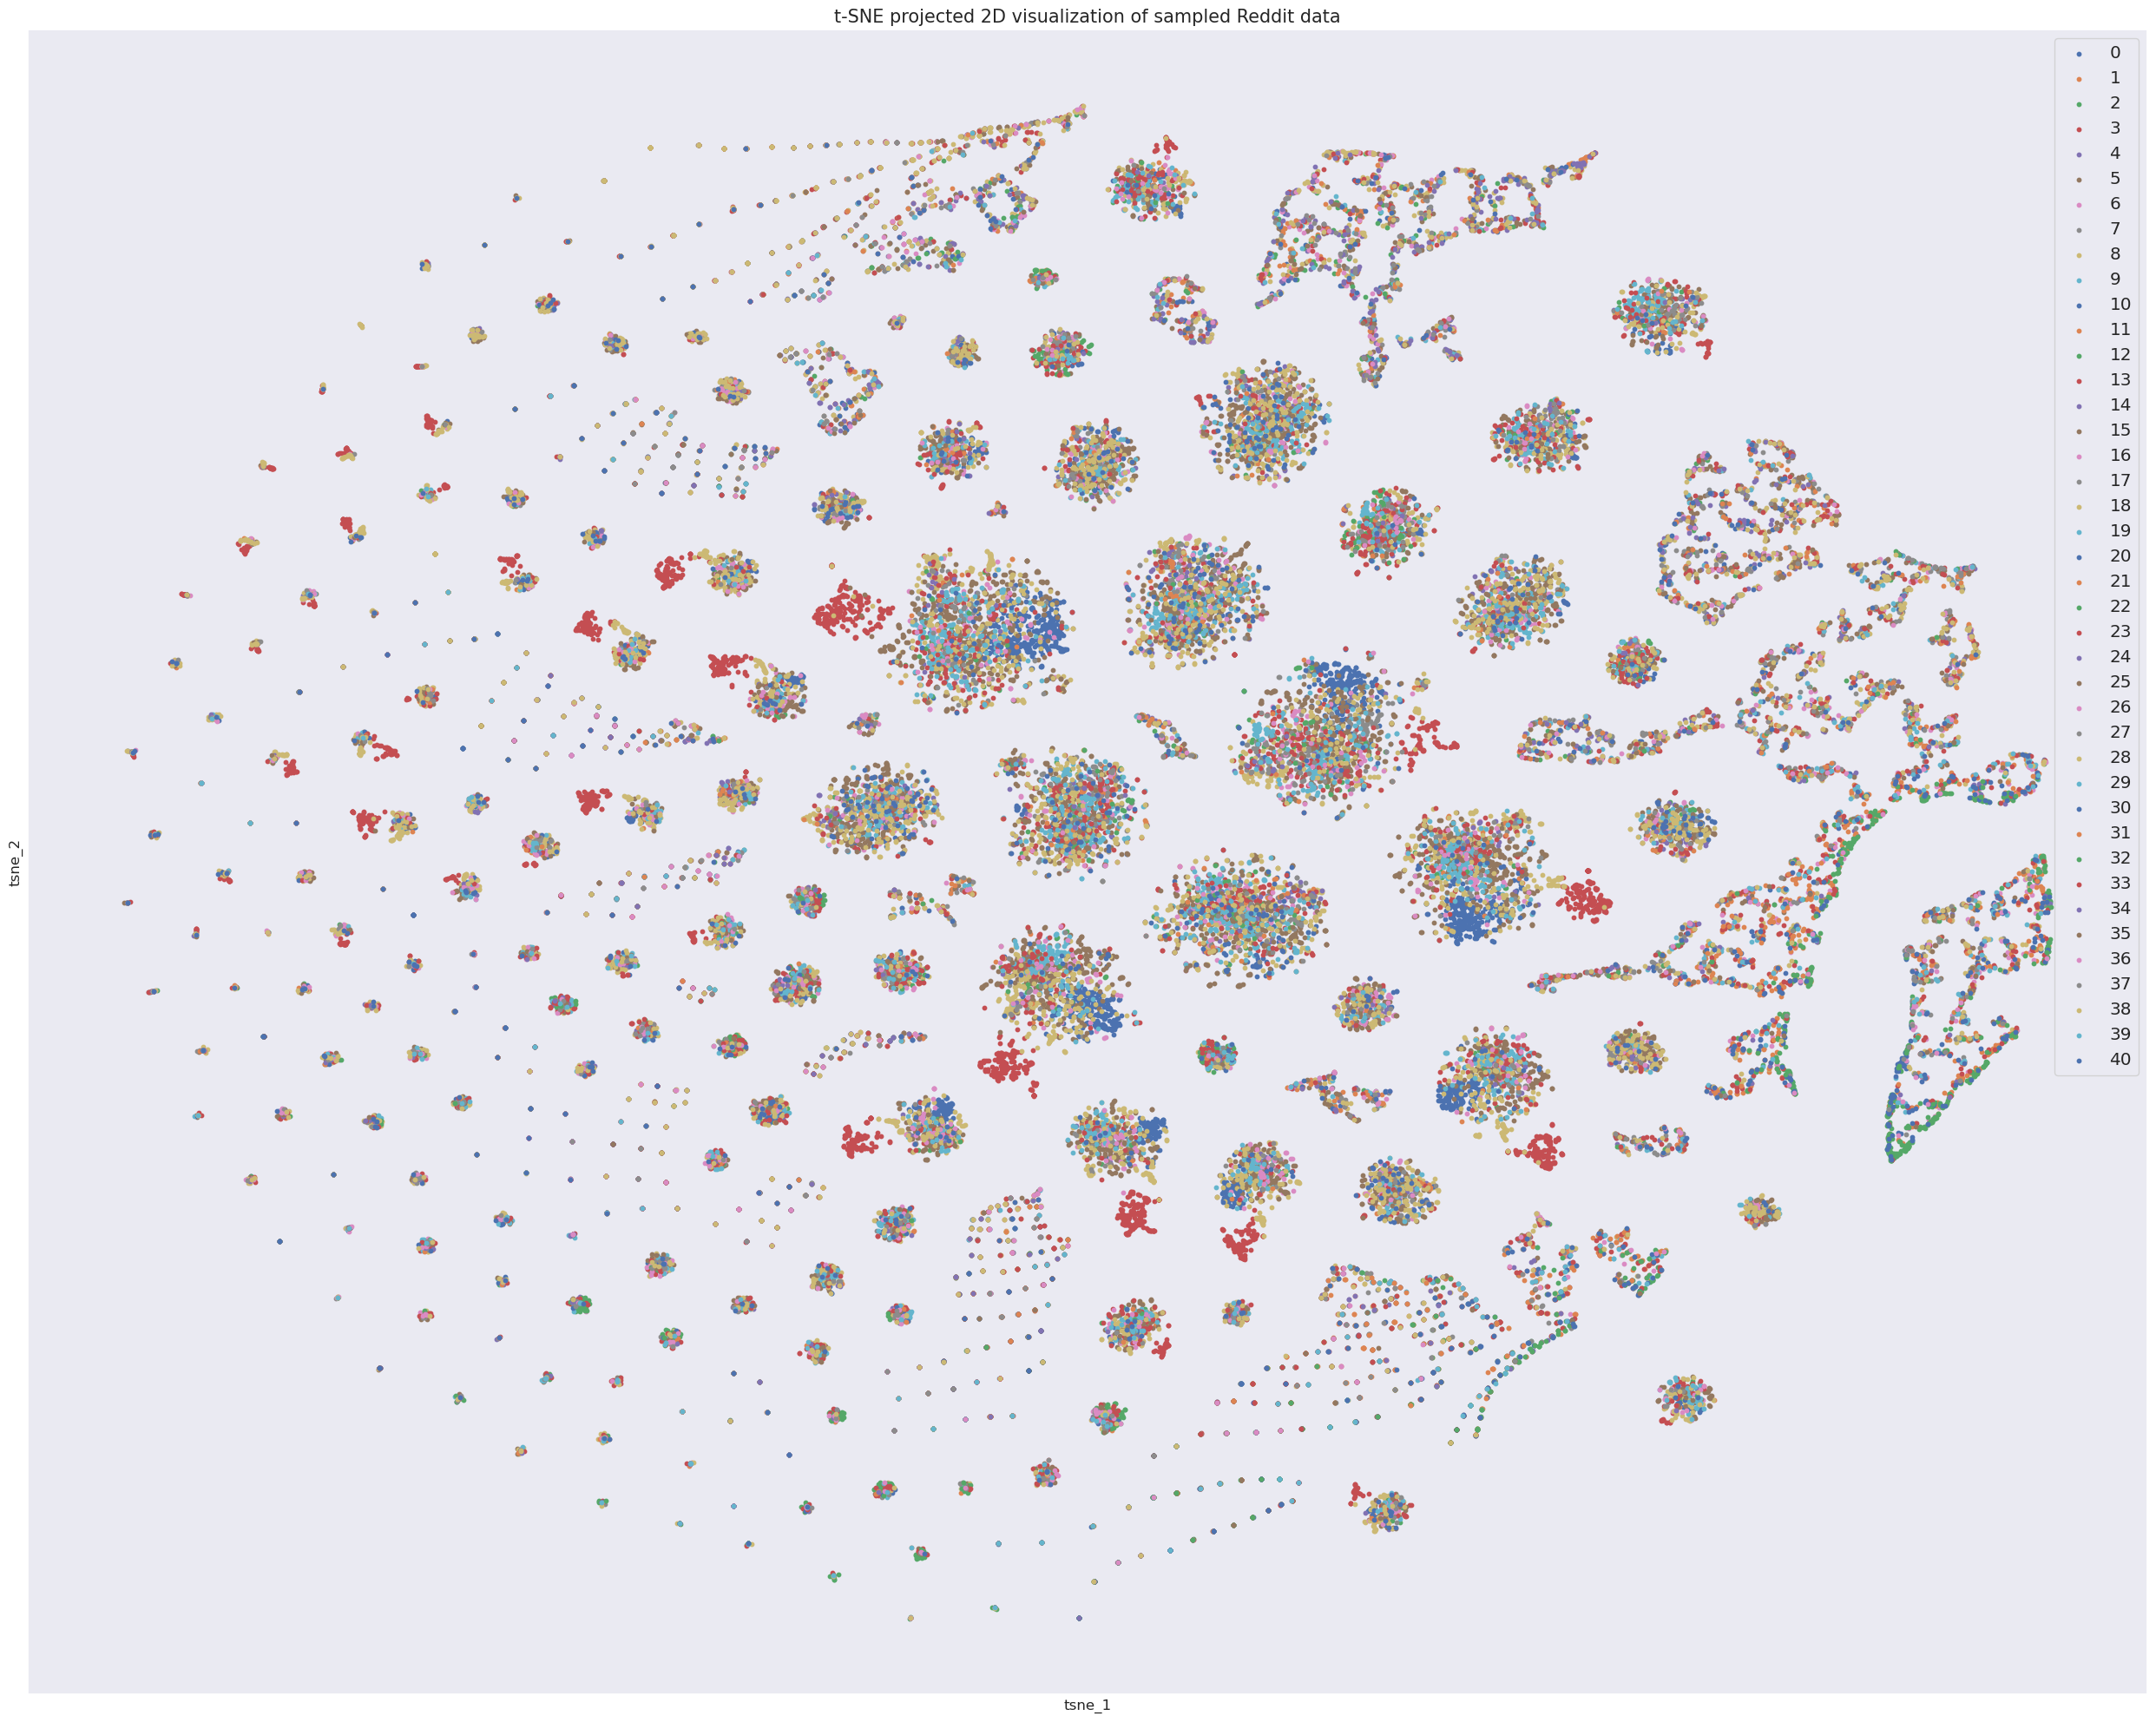

In [27]:
ts = [t for t in range(dataset.num_classes)]
cs = sns.color_palette(n_colors=dataset.num_classes)

Utils.scatter_plot(
    figsize=DEFAULT_VAL_FIG_SIZE
    , title_size=DEFAULT_VAL_TITLE_SIZE
    , label_size=DEFAULT_VAL_LABEL_SIZE
    , vm=Utils.get_scatter_plot_vm(
        data=pd.concat(
            axis=1
            , objs=[
                pd.DataFrame(
                    data=TSNE(
                        n_components=2
                    ).fit_transform(
                        X=df_X.iloc[:N_SAMPLES, :]
                    )
                    , columns=["tsne_1", "tsne_2"]
                )
                , df_Y.iloc[:N_SAMPLES, :]
            ]
        )
        , uni_ts=ts
        , labels_ts=ts
        , colors_ts=cs
        , col_xs="tsne_1"
        , col_ys="tsne_2"
        , label_xs="tsne_1"
        , label_ys="tsne_2"
        , col_ts="community"
        , title=f"t-SNE projected 2D visualization of sampled Reddit data"
    )
)

In [28]:
def to_subgraph_from_first_n_rows(data: pyg.data.Data, n_rows: int) -> pyg.data.Data:
    x = data.x[:n_rows]
    y = data.y[:n_rows]
    
    edge_mask = (data.edge_index[0] < n_rows) & (data.edge_index[1] < n_rows)
    edge_index = data.edge_index[:, edge_mask]
    
    subgraph_data = pyg.data.Data(x=x, edge_index=edge_index, y=y)

    return subgraph_data

In [29]:
g = pyg.utils.to_networkx(
    to_undirected=True
    , data=to_subgraph_from_first_n_rows(
        n_rows=N_SAMPLES
        , data=dataset
    )
)

In [30]:
def draw_graph(graph: nx.Graph, seed: int, title: str, node_colors: np.ndarray = None, color_map: str = 'viridis', figsize = DEFAULT_VAL_FIG_SIZE):
    if node_colors is None:
        partition = community_louvain.best_partition(graph)
        node_colors = np.array(list(partition.values()))
    
    pos = nx.spring_layout(graph, seed=seed)
    
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(graph, pos, node_size=10, cmap=plt.get_cmap(color_map), node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(graph, pos, alpha=0.75, width=1)
    plt.axis('off')
    plt.title(title, size=DEFAULT_VAL_TITLE_SIZE)
    plt.show()

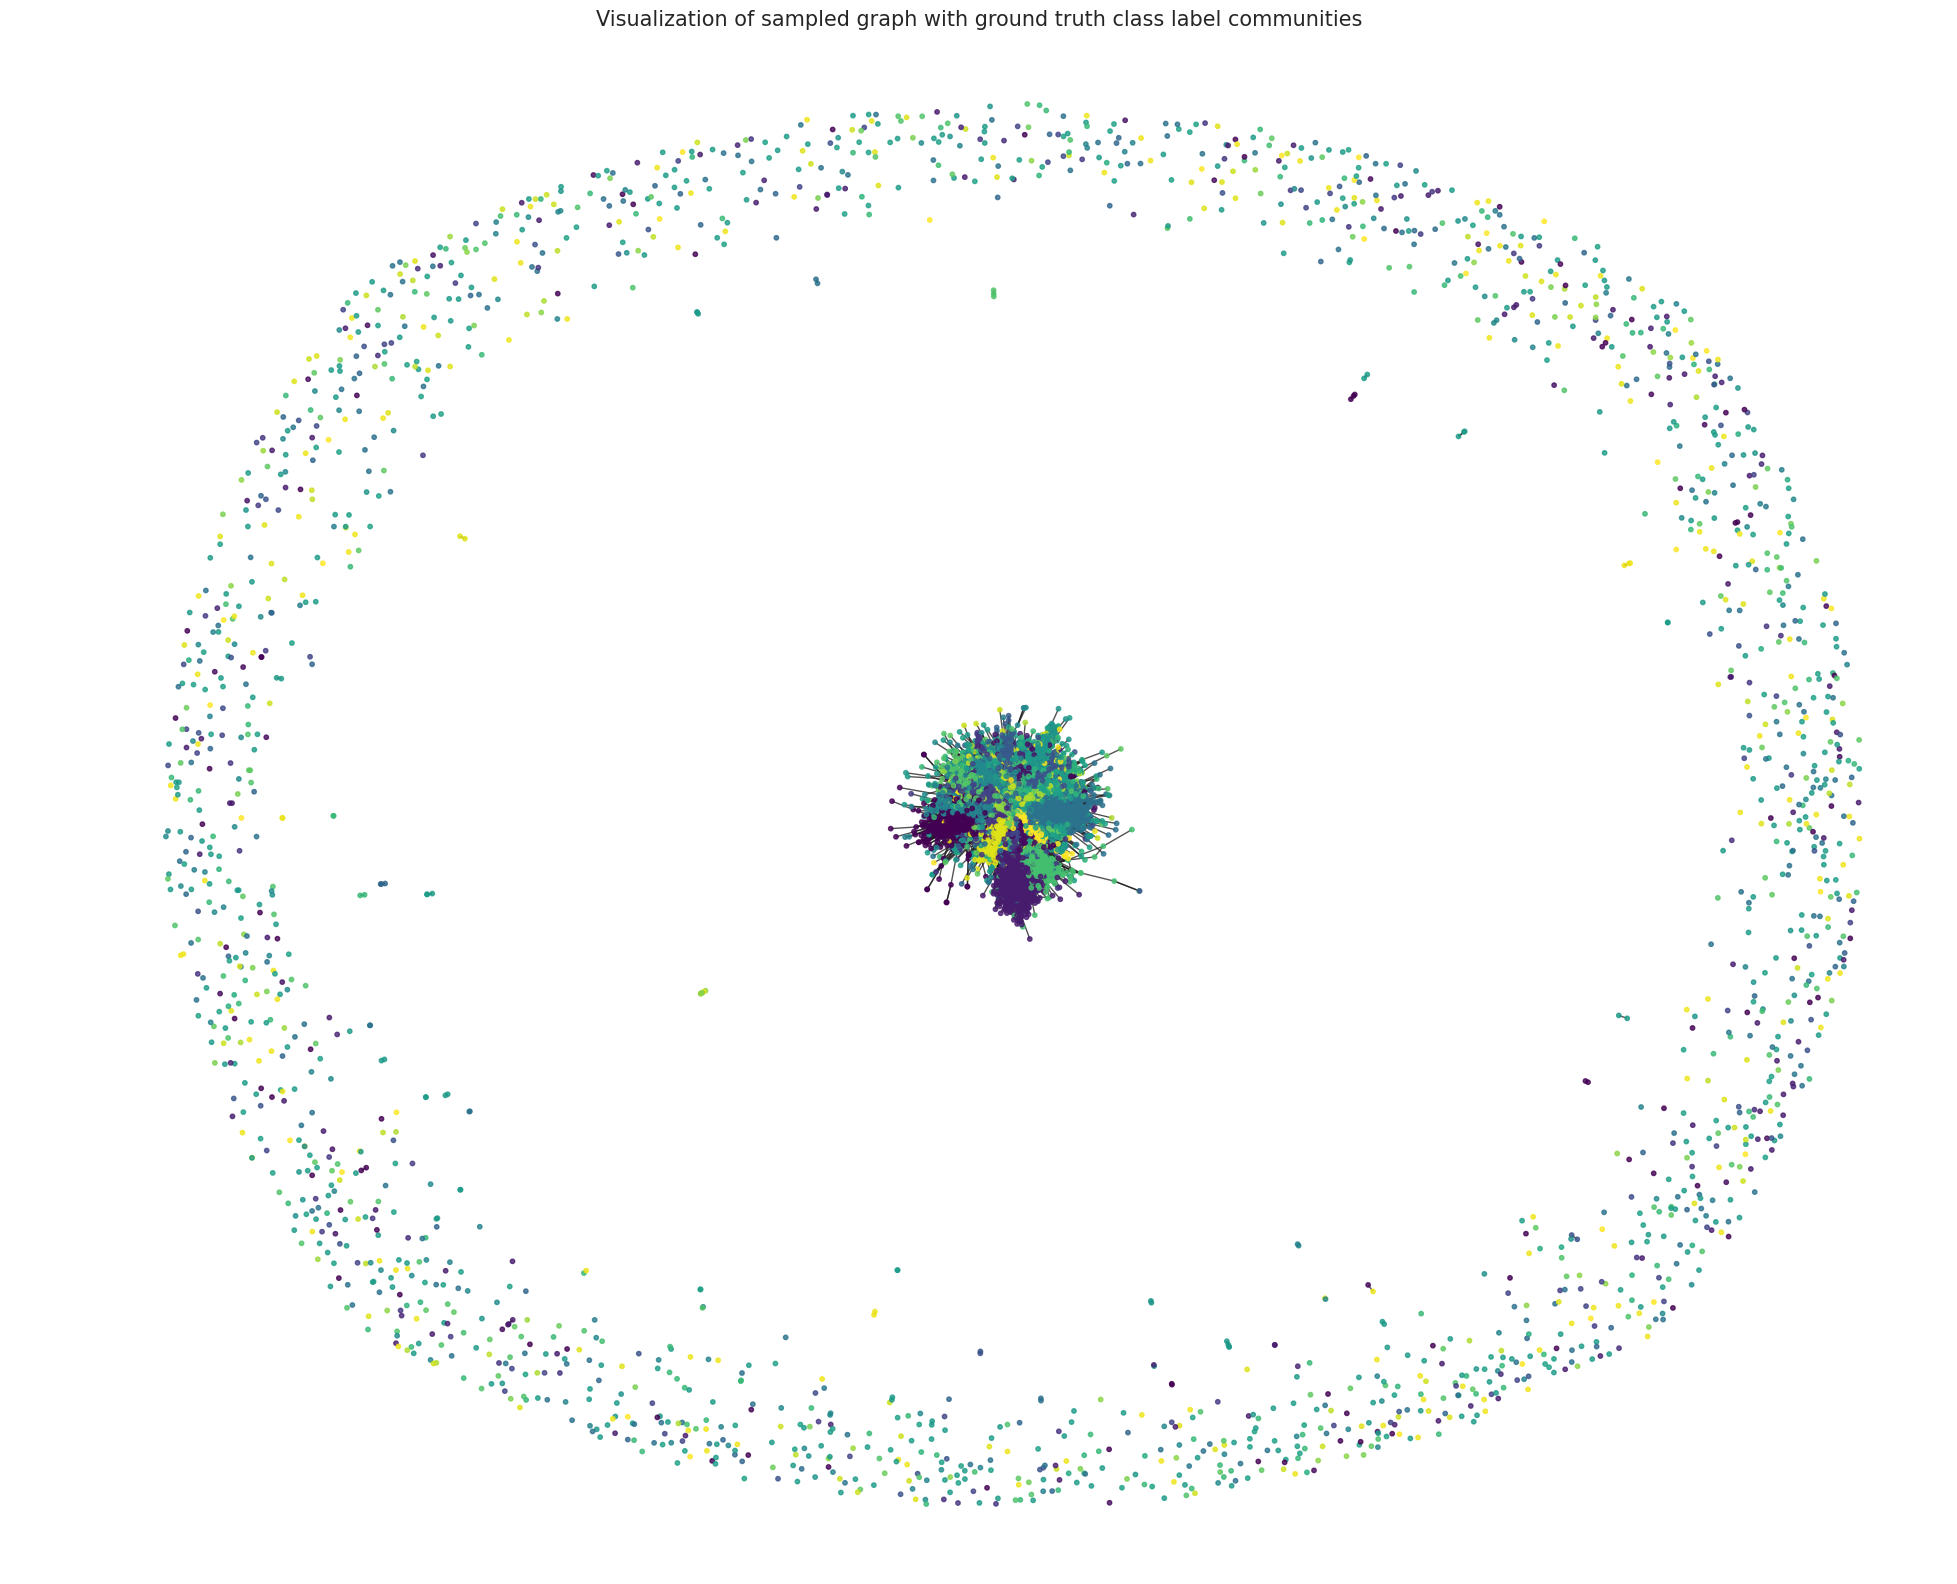

In [31]:
draw_graph(
    graph=g
    , seed=42
    , node_colors=df_Y.iloc[:N_SAMPLES, :].to_numpy()
    , title="Visualization of sampled graph with ground truth class label communities"
)

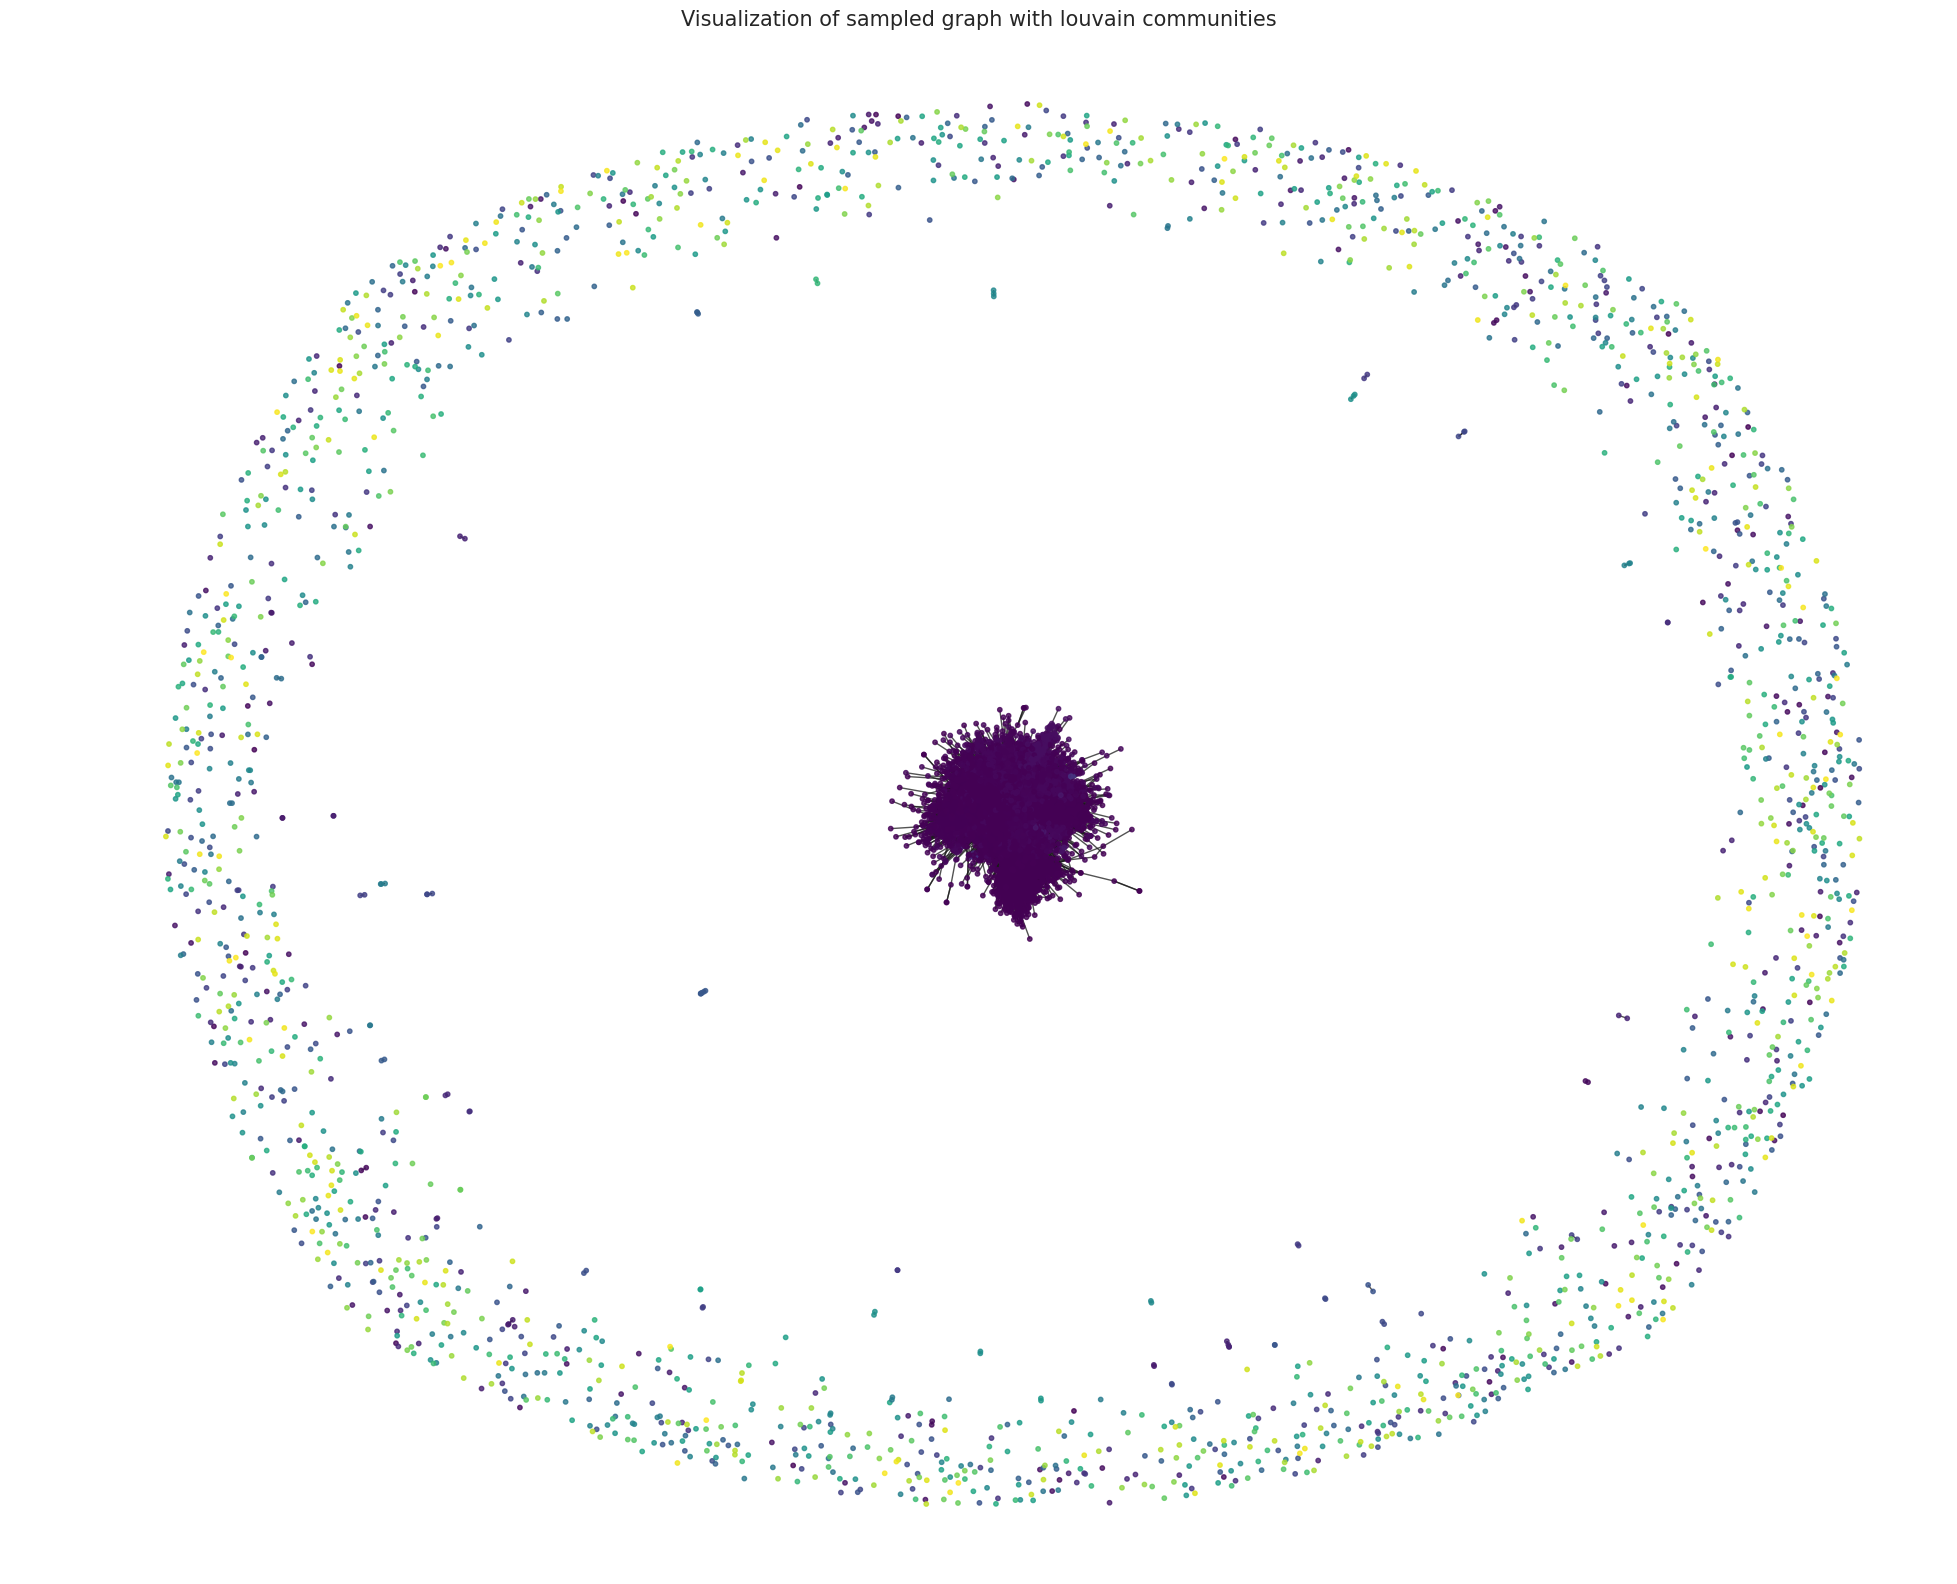

In [32]:
draw_graph(
    graph=g
    , seed=42
    , title="Visualization of sampled graph with louvain communities"
)

In [33]:
# number of edges in g
G_E = g.number_of_edges()

G_E

557817

In [34]:
# subgraph g degrees, reverse sorted
G_DEG = sorted(dict(g.degree()).values(), reverse=True)

G_avg_deg = sum(G_DEG) / len(G_DEG)

assert(G_avg_deg == 2 * G_E / N_SAMPLES)

print(G_avg_deg)

G_DEG[:10]

22.31268


[619, 595, 593, 565, 528, 526, 513, 507, 498, 493]

Text(0.5, 1.0, 'Graph g Degrees Distribution')

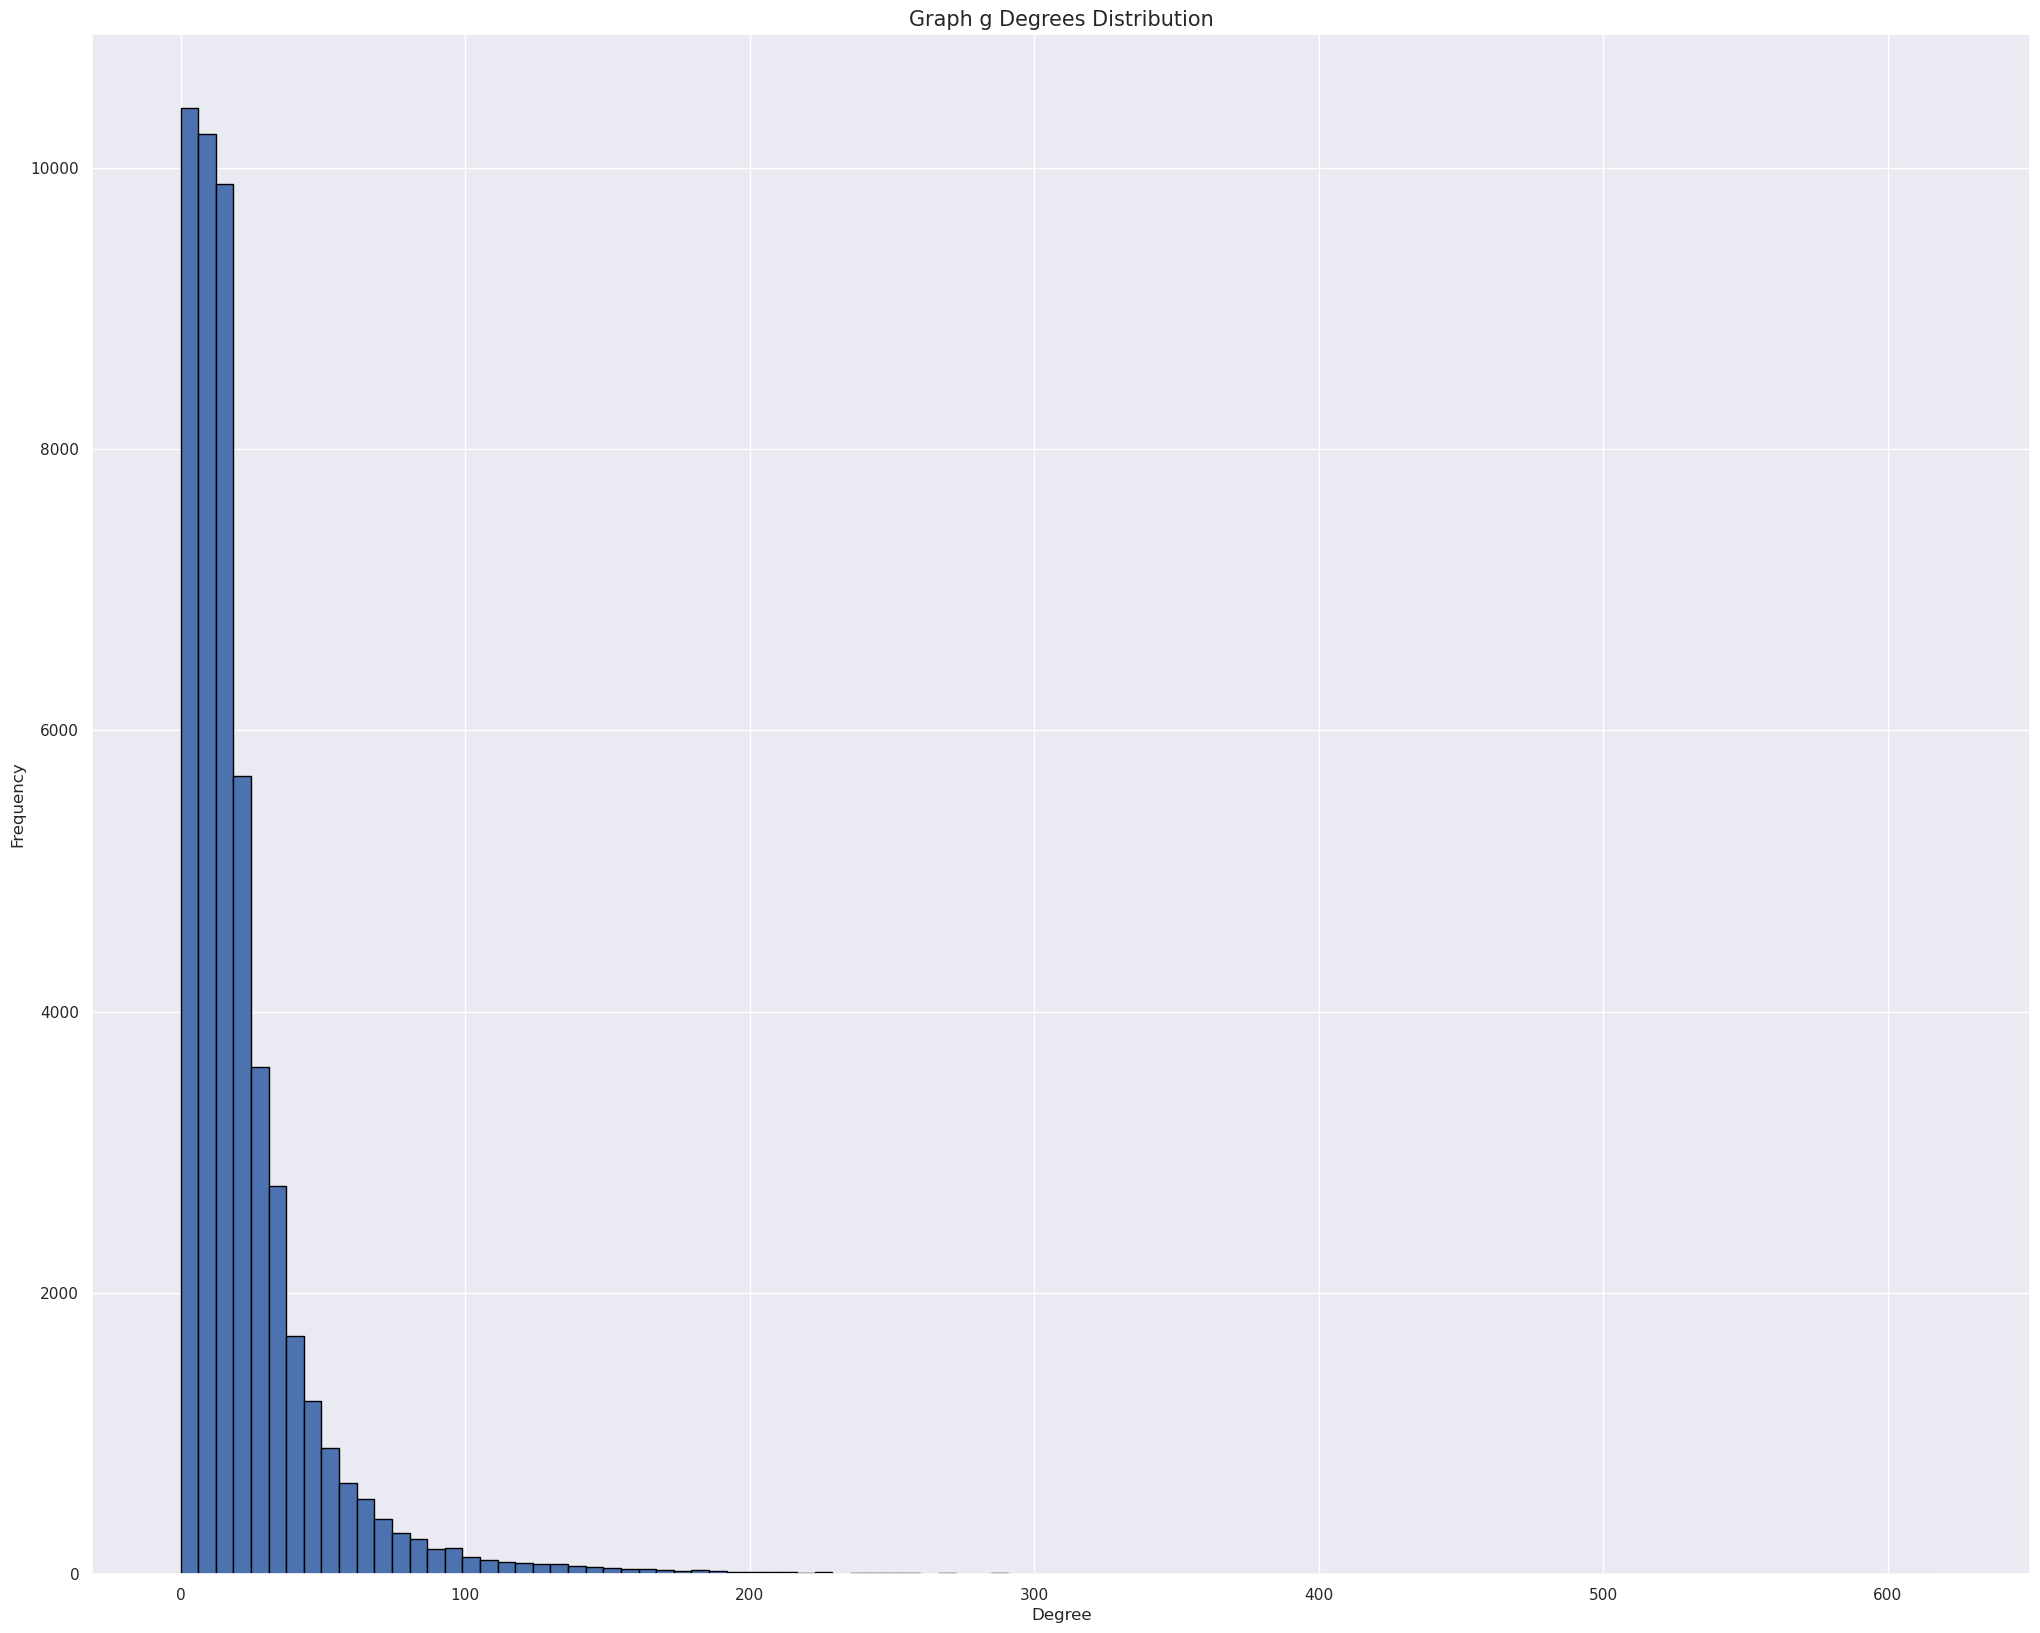

In [39]:
# plot degrees distribution for graph g
plt.figure(figsize=DEFAULT_VAL_FIG_SIZE)
plt.hist(G_DEG, bins=100, edgecolor="black")
plt.xlabel('Degree', size=DEFAULT_VAL_LABEL_SIZE)
plt.ylabel('Frequency', size=DEFAULT_VAL_LABEL_SIZE)
plt.title("Graph g Degrees Distribution", size=DEFAULT_VAL_TITLE_SIZE)

Text(0.5, 0, 'Rank')

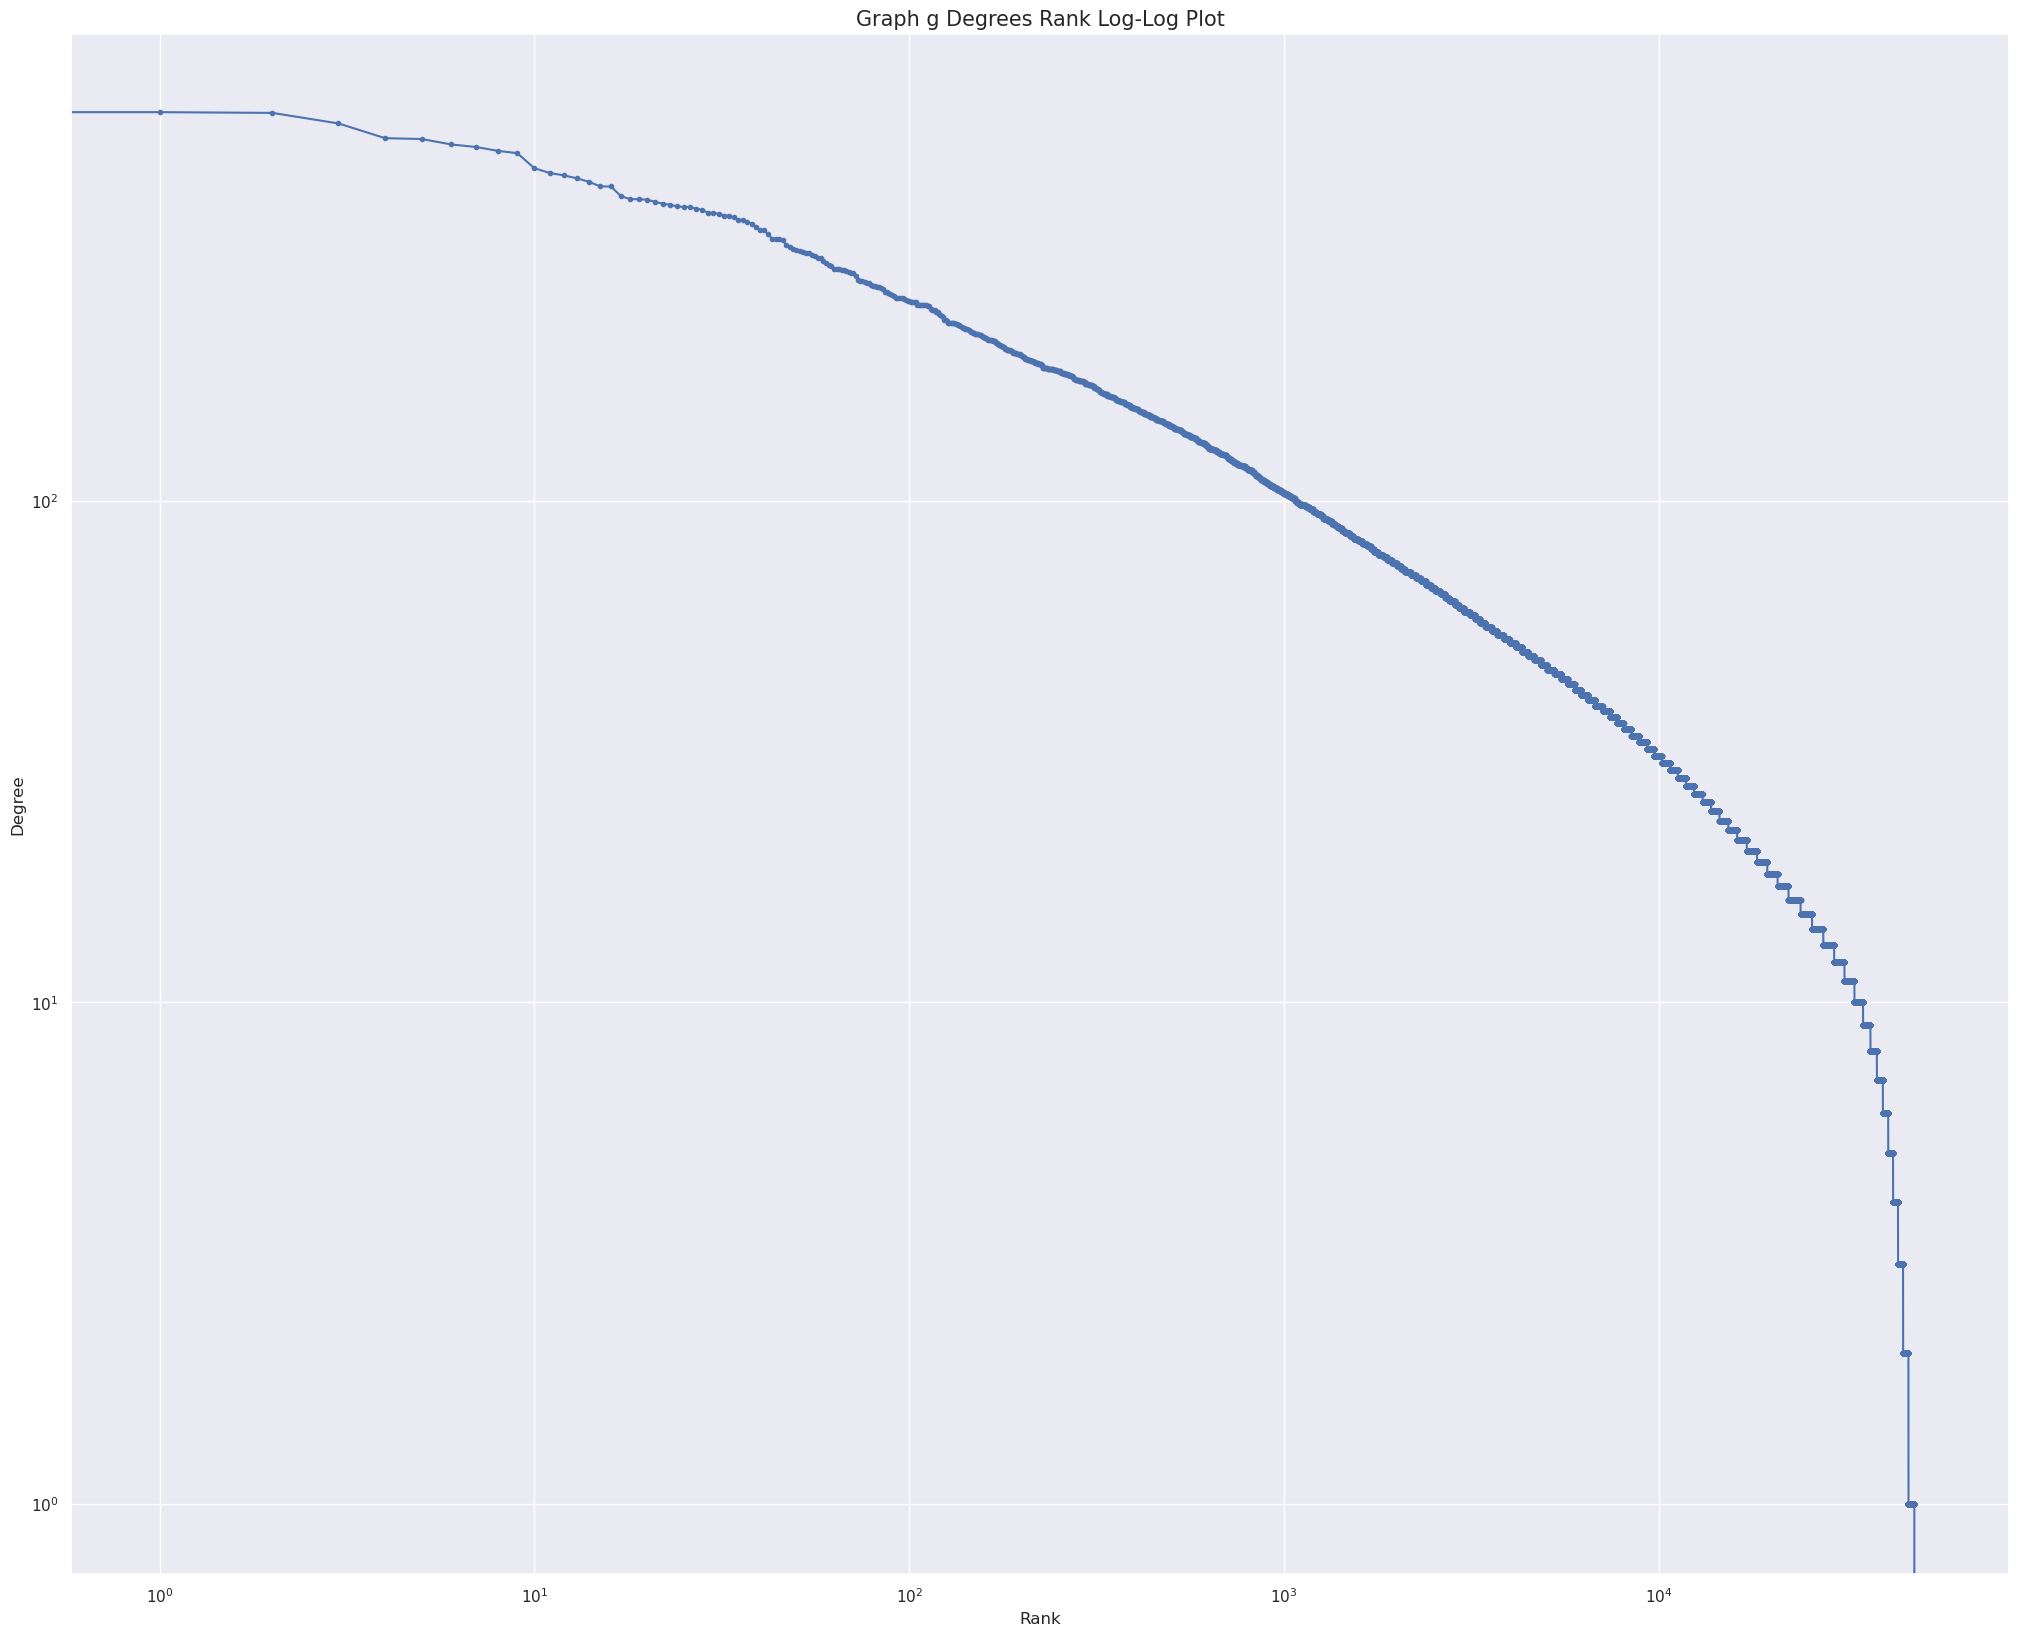

In [36]:
# plot degrees rank log-log plot of graph g
plt.figure(figsize=DEFAULT_VAL_FIG_SIZE)
plt.loglog(G_DEG, 'b-', marker='.')
plt.title('Graph g Degrees Rank Log-Log Plot', size=DEFAULT_VAL_TITLE_SIZE)
plt.ylabel('Degree', size=DEFAULT_VAL_LABEL_SIZE)
plt.xlabel('Rank', size=DEFAULT_VAL_LABEL_SIZE)

In [37]:
# graph g density shows it's very sparse
nx.density(g)

0.000446262525250505

In [38]:
# number of connected components in graph g
print(nx.number_connected_components(g))

[len(cc) for cc in nx.connected_components(g)]

2041


[47886,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 4,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
